# 02_Neighbourhoods: Sensor Distance Matrix & Dynamic Neighbor Definition

## Goal

This notebook constructs a **sensor–sensor distance matrix** for all 33 sensors and uses it to define dynamic spatial neighbourhoods.

### Key objectives:
1. **Compute pairwise Euclidean distances** between sensors using (X, Y) coordinates.
2. **Encode isolated/walled sensors** with a distance of **-1** to exclude them from neighbourhood calculations.
3. **Visualize the matrix** as a heatmap to identify clusters and isolated sensors.
4. **Extract distance statistics** (mean, median) to define a dynamic distance threshold.
5. **Identify close neighbours** for each sensor based on the distance threshold.
6. **Visualize neighbourhood relationships** in 2D space.

### Why this approach?
- **Data-driven thresholds:** Using median/mean avoids hard-coding neighbour counts and adapts to the spatial distribution of your floor plan.
- **Respects physical barriers:** Isolated sensors are explicitly excluded rather than relying on distance alone.
- **Modular functions:** All distance and neighbour functions can be extracted to `src/neighbourhoods.py` for reuse.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

sns.set(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)

In [6]:
root = Path('..')
data_dir = root / 'data'

# Try to load metadata_table.csv
metadata_path = data_dir / 'metadata_table.csv'
if not metadata_path.exists():
    raise FileNotFoundError(f"Expected {metadata_path.resolve()}")

df = pd.read_csv(metadata_path)

# Validate required columns
required_cols = ['ateccid', 'X', 'Y', 'is_sensor_isolated']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Data cleaning
df['ateccid'] = df['ateccid'].astype(str).str.strip()
df['X'] = pd.to_numeric(df['X'], errors='coerce')
df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
df['is_sensor_isolated'] = df['is_sensor_isolated'].astype(bool)

# Remove rows with missing coordinates
df_clean = df.dropna(subset=['X', 'Y']).copy()
df_clean = df_clean.reset_index(drop=True)

print(f"Loaded {len(df_clean)} sensors from {metadata_path.name}")
print(f"\nData summary:")
print(f"  Unique sensors: {df_clean['ateccid'].nunique()}")
print(f"  Total rows: {len(df_clean)}")
print(f"  Isolated sensors: {df_clean['is_sensor_isolated'].sum()}")
print(f"  Active sensors: {(~df_clean['is_sensor_isolated']).sum()}")

expected_sensors = 33
if len(df_clean) != expected_sensors:
    print(f"\n⚠️  Warning: Expected {expected_sensors} sensors, found {len(df_clean)}")

print(f"\nFirst few rows:")
display(df_clean[['ateccid', 'X', 'Y', 'is_sensor_isolated']].head())

Loaded 33 sensors from metadata_table.csv

Data summary:
  Unique sensors: 33
  Total rows: 33
  Isolated sensors: 10
  Active sensors: 23

First few rows:


,ateccid,X,Y,is_sensor_isolated
0,012353A0D79B8B6501,1994.2,-2564.7,False
1,0123C71FFE39D2DF01,2606.2,-2564.7,False
2,0123FCA88283696901,3222.2,-2564.7,False
3,0123B9C3BE0C085E01,4038.2,-2564.7,False
4,0123C2ABF23B69DA01,4650.2,-2564.7,False


## Build Distance Matrix

A **distance matrix** is a square symmetric matrix where each cell [i, j] represents the spatial distance (or relationship) between sensors i and j.

**Special handling for isolated sensors:**
- For any sensor marked as `is_sensor_isolated == True`, all distances to other sensors (except the diagonal) are set to **-1**.
- This ensures isolated sensors are excluded from later neighbourhood calculations.
- The diagonal remains **0** (distance from each sensor to itself).

In [8]:
def build_distance_matrix(
    df,
    id_col='ateccid',
    x_col='X',
    y_col='Y',
    isolated_col='is_sensor_isolated'
):
    """
    Build a sensor-sensor distance matrix from coordinate data.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing sensor data.
    id_col : str
        Column name for sensor IDs (default 'ateccid').
    x_col : str
        Column name for X coordinates (default 'X').
    y_col : str
        Column name for Y coordinates (default 'Y').
    isolated_col : str
        Column name for isolation flag (default 'is_sensor_isolated').
    
    Returns
    -------
    dist_matrix : pd.DataFrame
        Square distance matrix indexed and columned by sensor ID.
        - Diagonal: 0 (distance from sensor to itself)
        - Valid distances: Euclidean distance (always > 0)
        - Isolated pairs: -1 (blocked by wall/isolation)
    """
    n = len(df)
    sensor_ids = df[id_col].values
    x = df[x_col].values
    y = df[y_col].values
    isolated = df[isolated_col].values
    
    # Initialize matrix
    dist_matrix = np.zeros((n, n), dtype=float)
    
    # Compute pairwise distances
    for i in range(n):
        for j in range(i + 1, n):
            # Euclidean distance
            d = float(np.hypot(x[i] - x[j], y[i] - y[j]))
            
            # Check isolation: if either sensor is isolated, mark as -1
            if isolated[i] or isolated[j]:
                dist_matrix[i, j] = -1.0
                dist_matrix[j, i] = -1.0
            else:
                dist_matrix[i, j] = d
                dist_matrix[j, i] = d
    
    # Diagonal stays 0
    np.fill_diagonal(dist_matrix, 0.0)
    
    # Create DataFrame for easier access by sensor ID
    dist_df = pd.DataFrame(
        dist_matrix,
        index=sensor_ids,
        columns=sensor_ids
    )
    
    return dist_df


# Build the distance matrix
dist_matrix = build_distance_matrix(df_clean)

print(f"Distance matrix shape: {dist_matrix.shape}")
print(f"Matrix is symmetric: {np.allclose(dist_matrix.values, dist_matrix.values.T, equal_nan=True)}")

# Count special values
n_zero = (dist_matrix == 0).sum().sum()
n_blocked = (dist_matrix == -1).sum().sum()
n_valid = ((dist_matrix > 0) & (dist_matrix != -1)).sum().sum()

print(f"\nMatrix content:")
print(f"  Diagonal (0): {n_zero // 2}")  # Divide by 2 because each 0 appears twice (i,i)
print(f"  Blocked by isolation (-1): {n_blocked // 2}")  # Divide by 2 for symmetry
print(f"  Valid distances (>0): {n_valid // 2}")  # Divide by 2 for symmetry

Distance matrix shape: (33, 33)
Matrix is symmetric: True

Matrix content:
  Diagonal (0): 16
  Blocked by isolation (-1): 275
  Valid distances (>0): 253


## Visualize Distance Matrix as Heatmap

The heatmap shows sensor–sensor distances with a special treatment for isolated sensors:
- **Dark blue:** Very close sensors (small distance, high similarity)
- **Light yellow:** Distant sensors (large distance)
- **Grey:** Blocked pairs (-1), indicating at least one sensor is isolated

Rows/columns full of grey (-1) are isolated sensors and will have no valid neighbours.

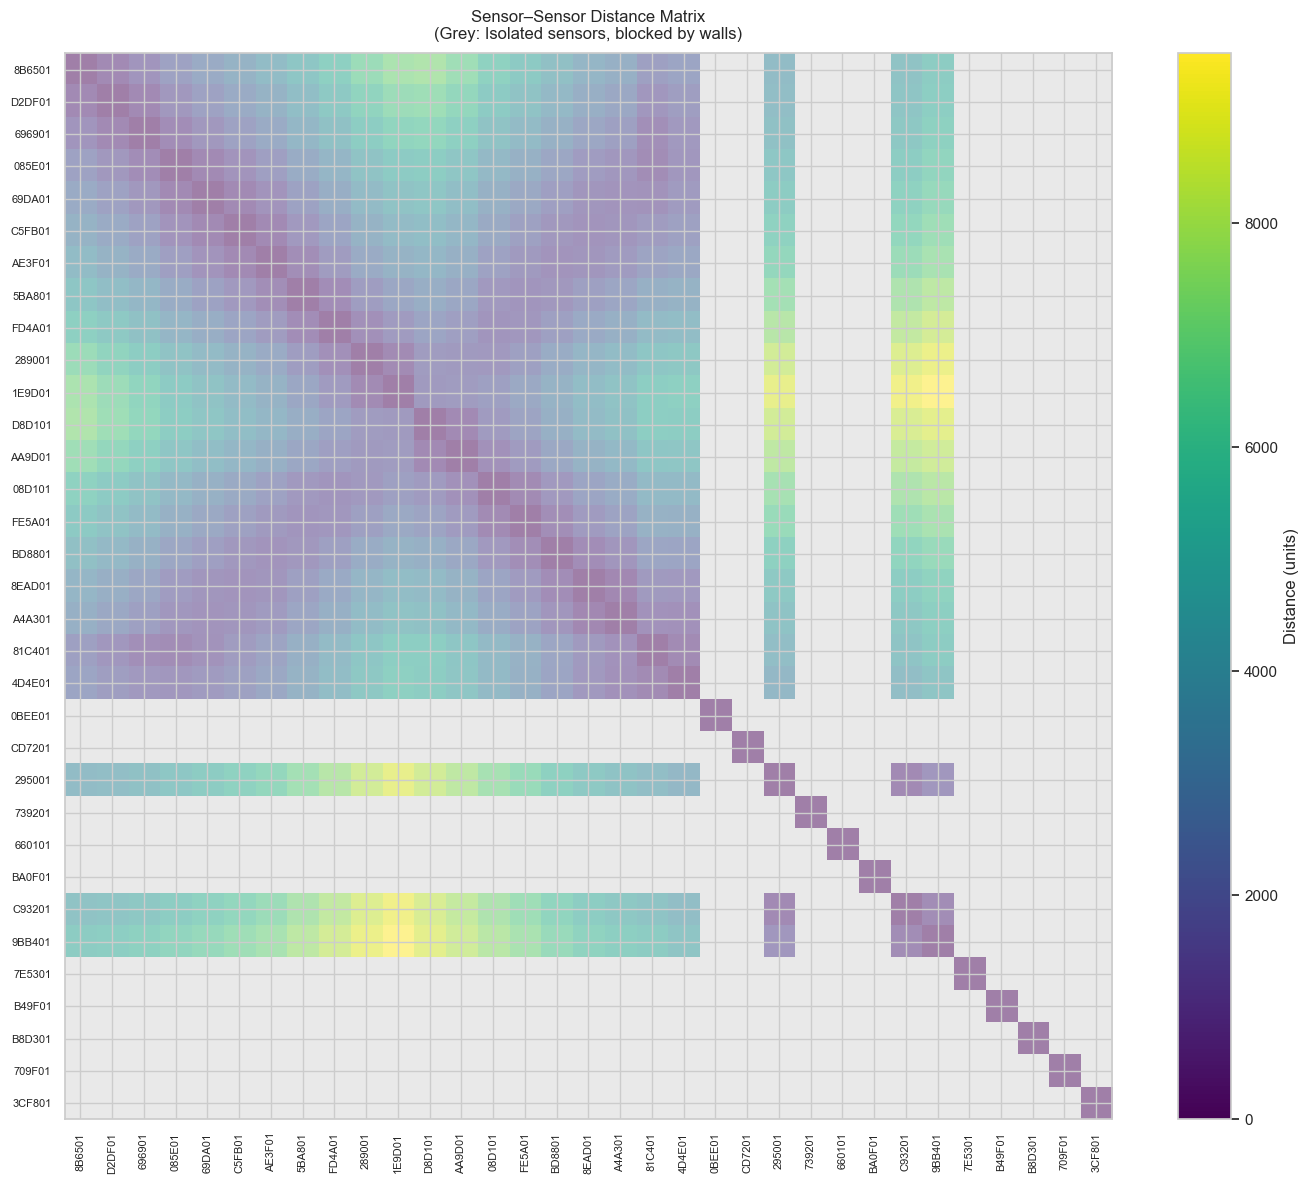

Heatmap plotted for 33 sensors.


In [9]:
# Create a custom colormap: -1 → grey, 0 → white, positive → viridis
from matplotlib.colors import ListedColormap

# Extract the matrix as numpy for visualization
dist_array = dist_matrix.values.copy()

# Create a masked array: mask out -1 so it can be colored separately
masked_dist = np.ma.masked_where(dist_array == -1, dist_array)

fig, ax = plt.subplots(figsize=(14, 12))

# Plot valid distances with viridis colormap
im = ax.imshow(
    masked_dist,
    cmap='viridis',
    aspect='auto',
    origin='upper',
    vmin=0,
    vmax=np.nanmax(masked_dist)
)

# Plot -1 values as grey
isolated_mask = (dist_array == -1)
ax.imshow(isolated_mask, cmap=ListedColormap(['white', 'lightgrey']), aspect='auto', origin='upper', alpha=0.5)

# Colorbar
cbar = plt.colorbar(im, ax=ax, label='Distance (units)')

# Labels
ax.set_xticks(range(len(dist_matrix)))
ax.set_yticks(range(len(dist_matrix)))
sensor_labels = [s[-6:] for s in dist_matrix.index]  # Last 6 chars of sensor ID
ax.set_xticklabels(sensor_labels, rotation=90, fontsize=8)
ax.set_yticklabels(sensor_labels, fontsize=8)

plt.title('Sensor–Sensor Distance Matrix\n(Grey: Isolated sensors, blocked by walls)', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

print(f"Heatmap plotted for {len(dist_matrix)} sensors.")

## Distance Statistics & Dynamic Thresholds

Extract valid (positive, non-isolated) distances and compute summary statistics. These statistics inform the selection of a distance threshold for "close neighbours".

Distance Statistics (valid distances only):
  Count: 506
  Min:   484.00
  Q25:   1651.41
  Median:3222.17
  Mean:  3598.59
  Q75:   5182.58
  Max:   9514.63
  Std:   2178.91

Thresholds for dynamic neighbour definition:

Option A (Mean):   3598.59
  → Includes all pairs within 3598.59 units.
  → Sensitive to outliers (very distant sensor pairs).

Option B (Median): 3222.17
  → Includes all pairs within 3222.17 units.
  → More robust; half of distances are below, half above.

💡 Recommendation: Use median for stable, data-driven neighbours.


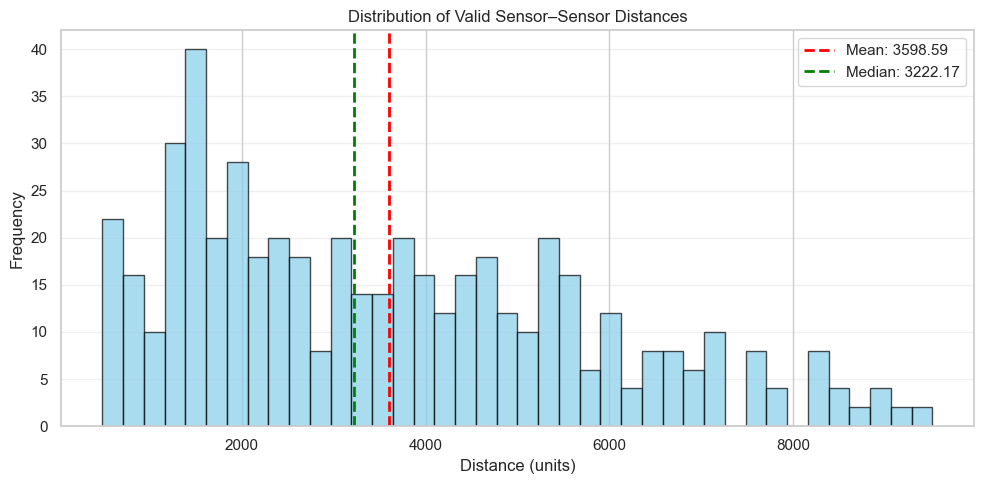

In [10]:
# Extract valid distances (off-diagonal, > 0, != -1)
dist_array_flat = dist_matrix.values.flatten()
valid_distances = dist_array_flat[(dist_array_flat > 0) & (dist_array_flat != -1)]

# Compute statistics
stats = {
    'count': len(valid_distances),
    'min': valid_distances.min(),
    'max': valid_distances.max(),
    'mean': valid_distances.mean(),
    'median': np.median(valid_distances),
    'std': valid_distances.std(),
    'q25': np.percentile(valid_distances, 25),
    'q75': np.percentile(valid_distances, 75),
}

print("Distance Statistics (valid distances only):")
print(f"  Count: {stats['count']}")
print(f"  Min:   {stats['min']:.2f}")
print(f"  Q25:   {stats['q25']:.2f}")
print(f"  Median:{stats['median']:.2f}")
print(f"  Mean:  {stats['mean']:.2f}")
print(f"  Q75:   {stats['q75']:.2f}")
print(f"  Max:   {stats['max']:.2f}")
print(f"  Std:   {stats['std']:.2f}")

# Define threshold options
print("\n" + "="*60)
print("Thresholds for dynamic neighbour definition:")
print("="*60)

threshold_mean = stats['mean']
threshold_median = stats['median']

print(f"\nOption A (Mean):   {threshold_mean:.2f}")
print(f"  → Includes all pairs within {threshold_mean:.2f} units.")
print(f"  → Sensitive to outliers (very distant sensor pairs).")

print(f"\nOption B (Median): {threshold_median:.2f}")
print(f"  → Includes all pairs within {threshold_median:.2f} units.")
print(f"  → More robust; half of distances are below, half above.")

print("\n💡 Recommendation: Use median for stable, data-driven neighbours.")

# Plot histogram of valid distances
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(valid_distances, bins=40, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(threshold_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {threshold_mean:.2f}')
ax.axvline(threshold_median, color='green', linestyle='--', linewidth=2, label=f'Median: {threshold_median:.2f}')
ax.set_xlabel('Distance (units)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Valid Sensor–Sensor Distances')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Identify Dynamic Neighbours

For each sensor, identify its "close neighbours" using a distance threshold. A sensor j is a neighbour of sensor i if:
- The distance dist(i, j) > 0 (exclude self and -1 blocks)
- The distance dist(i, j) <= threshold

In [ ]:
def find_neighbours(dist_matrix, threshold, exclude_self=True):
    """
    For each sensor, identify close neighbours based on distance threshold.
    
    Parameters
    ----------
    dist_matrix : pd.DataFrame
        Square distance matrix (indexed by sensor ID).
    threshold : float
        Maximum distance to consider two sensors neighbours.
    exclude_self : bool
        If True, exclude diagonal (distance 0).
    
    Returns
    -------
    neighbours : dict
        Dictionary mapping sensor_id -> list of neighbour_ids (sorted by distance).
    """
    neighbours = {}
    
    for sensor_i in dist_matrix.index:
        # Get all distances for this sensor
        distances = dist_matrix.loc[sensor_i]
        
        # Filter: exclude self (0), exclude blocked (-1), include only <= threshold
        valid = (distances > 0) & (distances != -1) & (distances <= threshold)
        
        # Get list of neighbour IDs sorted by distance
        neighbour_list = distances[valid].sort_values().index.tolist()
        neighbours[sensor_i] = neighbour_list
    
    return neighbours


# Compute neighbours using median threshold
threshold_used = threshold_median
neighbours = find_neighbours(dist_matrix, threshold=threshold_used)

print(f"Neighbours identified using threshold = {threshold_used:.2f}\n")

# Summary statistics
neighbour_counts = [len(nbrs) for nbrs in neighbours.values()]
print("Neighbourhood Summary:")
print(f"  Min neighbours: {min(neighbour_counts)}")
print(f"  Max neighbours: {max(neighbour_counts)}")
print(f"  Mean neighbours: {np.mean(neighbour_counts):.2f}")
print(f"  Median neighbours: {np.median(neighbour_counts):.2f}")

# Show example neighbourhoods
print("\n" + "="*60)
print("Example Neighbourhoods:")
print("="*60)

# Isolated sensors
isolated_sensors = df_clean[df_clean['is_sensor_isolated']]['ateccid'].values
if len(isolated_sensors) > 0:
    print(f"\nIsolated sensor (should have 0 neighbours):")
    example_isolated = isolated_sensors[0]
    print(f"  {example_isolated}: {neighbours[example_isolated]}")

# Active sensors with varying neighbour counts
active_sensors = df_clean[~df_clean['is_sensor_isolated']]['ateccid'].values
if len(active_sensors) >= 3:
    print(f"\nActive sensors with varying counts:")
    for s in active_sensors[:3]:
        nbrs = neighbours[s]
        count = len(nbrs)
        print(f"  {s}: {count} neighbours")
        if count > 0 and count <= 5:
            print(f"      → {nbrs}")
        elif count > 5:
            print(f"      → {nbrs[:5]} ... (+{count - 5} more)")

Neighbours identified using threshold = 3222.17

Neighbourhood Summary:
  Min neighbours: 0
  Max neighbours: 16
  Mean neighbours: 7.70
  Median neighbours: 9.00

Example Neighbourhoods:

Isolated sensor (should have 0 neighbours):
  012335521BE30BEE01: []

Active sensors with varying counts:
  012353A0D79B8B6501: 7 neighbours
      → ['0123C71FFE39D2DF01', '0123FCA88283696901', '0123874CF37F81C401', '0123B9C3BE0C085E01', '0123B1E797C64D4E01'] ... (+2 more)
  0123C71FFE39D2DF01: 9 neighbours
      → ['012353A0D79B8B6501', '0123FCA88283696901', '0123874CF37F81C401', '0123B9C3BE0C085E01', '0123B1E797C64D4E01'] ... (+4 more)
  0123FCA88283696901: 11 neighbours
      → ['0123C71FFE39D2DF01', '0123B9C3BE0C085E01', '0123874CF37F81C401', '012353A0D79B8B6501', '0123C2ABF23B69DA01'] ... (+6 more)


## Visualize Neighbourhoods in 2D Space

Plot sensors on the floor plan (X, Y coordinates) and draw lines connecting each sensor to its close neighbours. This shows spatial clusters and isolated sensors visually.

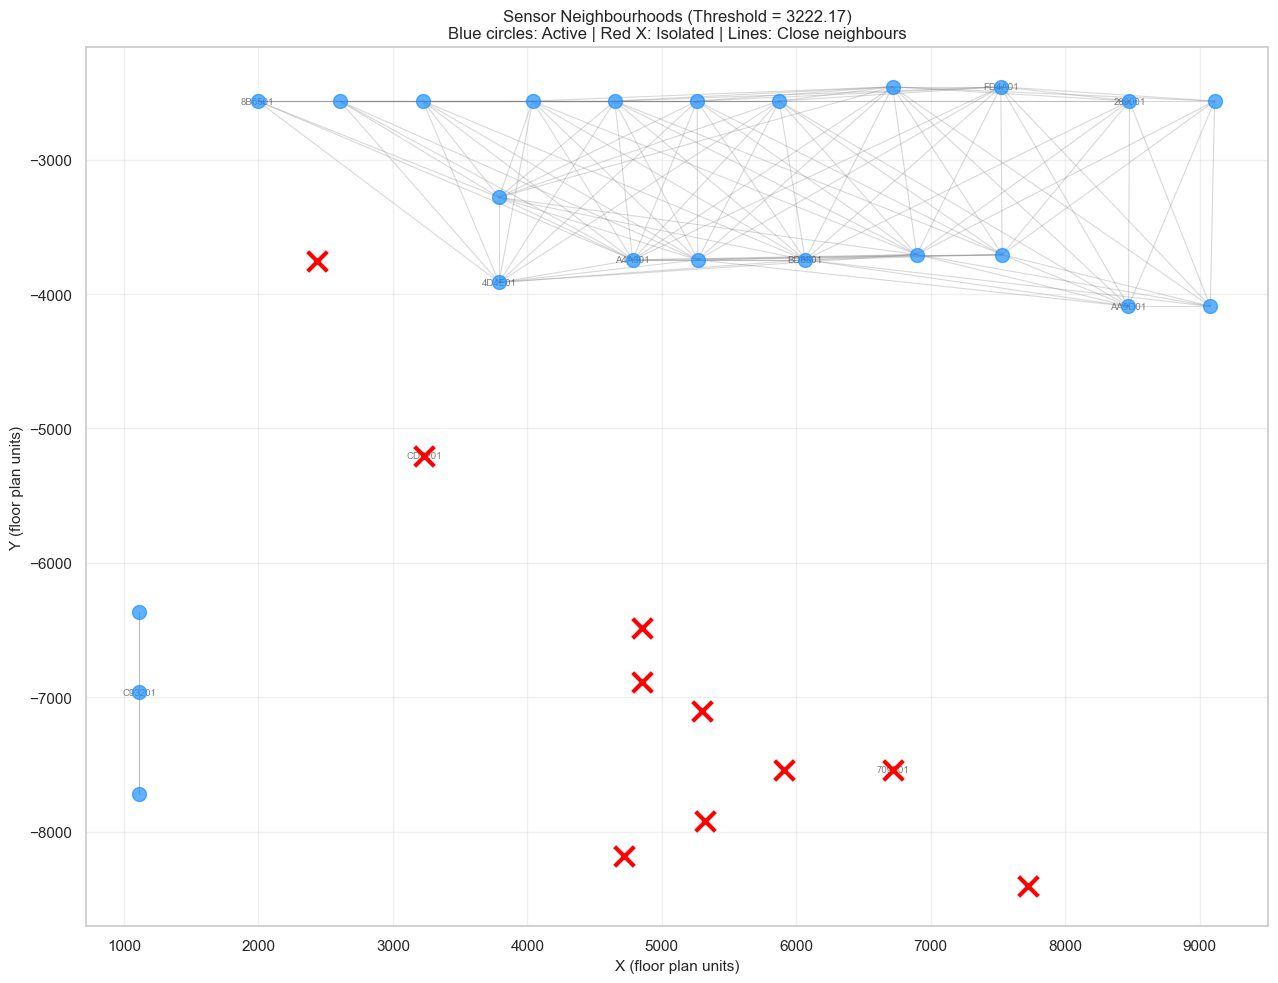

Plotted 33 sensors and 127 neighbourhood edges.


In [12]:
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all sensors
for idx, row in df_clean.iterrows():
    sensor_id = row['ateccid']
    x, y = row['X'], row['Y']
    is_isolated = row['is_sensor_isolated']
    
    # Color and marker based on isolation
    if is_isolated:
        ax.scatter(x, y, s=200, c='red', marker='x', linewidth=3, label='Isolated' if idx == df_clean[df_clean['is_sensor_isolated']].index[0] else '', zorder=5)
    else:
        ax.scatter(x, y, s=100, c='dodgerblue', marker='o', alpha=0.7, zorder=4)

# Draw edges (neighbourhoods)
drawn_edges = set()
for sensor_i, nbrs in neighbours.items():
    x_i = df_clean[df_clean['ateccid'] == sensor_i]['X'].values[0]
    y_i = df_clean[df_clean['ateccid'] == sensor_i]['Y'].values[0]
    
    for sensor_j in nbrs:
        # Only draw once (avoid duplication)
        edge = tuple(sorted([sensor_i, sensor_j]))
        if edge in drawn_edges:
            continue
        drawn_edges.add(edge)
        
        x_j = df_clean[df_clean['ateccid'] == sensor_j]['X'].values[0]
        y_j = df_clean[df_clean['ateccid'] == sensor_j]['Y'].values[0]
        
        ax.plot([x_i, x_j], [y_i, y_j], 'gray', alpha=0.3, linewidth=0.8, zorder=1)

# Add labels for a few example sensors (to avoid clutter)
sample_size = 10
for idx, row in df_clean.sample(min(sample_size, len(df_clean)), random_state=42).iterrows():
    sensor_id = row['ateccid'][-6:]  # Last 6 chars
    ax.text(row['X'], row['Y'], sensor_id, fontsize=7, ha='center', va='center', alpha=0.6)

ax.set_xlabel('X (floor plan units)', fontsize=11)
ax.set_ylabel('Y (floor plan units)', fontsize=11)
ax.set_title(f'Sensor Neighbourhoods (Threshold = {threshold_used:.2f})\nBlue circles: Active | Red X: Isolated | Lines: Close neighbours', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"Plotted {len(neighbours)} sensors and {len(drawn_edges)} neighbourhood edges.")

## Save Neighbourhood Data

Export the distance matrix and neighbour relationships for use in later analyses.

In [13]:
# Save distance matrix
dist_matrix_path = data_dir / 'distance_matrix.csv'
dist_matrix.to_csv(dist_matrix_path)
print(f"✓ Saved distance matrix to {dist_matrix_path.name}")

# Save neighbours as JSON for easy loading
import json

neighbours_path = data_dir / 'neighbours.json'
with open(neighbours_path, 'w') as f:
    json.dump(neighbours, f, indent=2)
print(f"✓ Saved neighbours to {neighbours_path.name}")

# Summary output
print(f"\nExport Summary (threshold = {threshold_used:.2f}):")
print(f"  Distance matrix: {dist_matrix.shape}")
print(f"  Unique neighbours across all sensors: {len(set(v for vlist in neighbours.values() for v in vlist))}")
print(f"  Total edges: {len(drawn_edges)}")

✓ Saved distance matrix to distance_matrix.csv
✓ Saved neighbours to neighbours.json

Export Summary (threshold = 3222.17):
  Distance matrix: (33, 33)
  Unique neighbours across all sensors: 23
  Total edges: 127


## Analysis: Why a Full Distance Matrix?

**Write-up placeholder:**

A full distance matrix is a fundamental representation in Wireless Sensor Networks (WSN) and spatial analysis because:

1. **Symmetry & directness:** Every pairwise relationship is explicit and bidirectional, making it easy to query "who are the neighbours of sensor X?" or compute aggregate statistics.

2. **Wall-aware:** By encoding isolated/walled regions as -1, we avoid falsely connecting sensors separated by physical barriers, which is essential for indoor environments.

3. **Flexibility:** Distance matrices can be post-processed in many ways (threshold-based, graph-based, clustering) without recomputing raw distances.

4. **Reproducibility:** Once saved, the same matrix can be used across multiple downstream analyses (neighbourhood selection, spatial outlier detection, map-matching, etc.).

### Mean vs. Median for Thresholds

- **Mean:** $\bar{d} = \frac{1}{n} \sum_i d_i$  
  Pros: Uses all data; interpretable.  
  Cons: Sensitive to long-tail outliers (very distant sensor pairs).

- **Median:** $d_{50\%}$ = value where 50% of distances are below/above.  
  Pros: Robust; always represents central tendency.  
  Cons: Ignores exact values beyond the split.

**Recommendation:** Use median for sensor networks because the distribution of distances often has long tails (a few sensor pairs very far apart), which can inflate the mean and lead to too-loose thresholds.



## Summary & Next Steps

### Key Takeaways

1. **Distance Matrix:** Built a symmetric $33 \times 33$ matrix encoding all sensor–sensor Euclidean distances, with -1 for isolated pairs.

2. **Data-Driven Thresholds:** Used the empirical distribution (median distance) to define a dynamic neighbour threshold, avoiding hard-coded counts.

3. **Isolated Sensors Respected:** Sensors marked `is_sensor_isolated = True` have no valid neighbours (all distances set to -1).

4. **Modular Functions:** `build_distance_matrix()` and `find_neighbours()` are pure functions (no notebook-specific code) and can be extracted to `src/neighbourhoods.py`.

### Future Work

- **Move functions to `src/neighbourhoods.py`** for reuse across notebooks.
- **Add unit tests** for `build_distance_matrix()` and `find_neighbours()`.
- **Explore alternative thresholds:** k-nearest neighbours, percentile-based, or adaptive per location type.
- **Weighted neighbourhoods:** Incorporate signal strength, wall materials, or location type into the distance metric.
- **Graph-based analysis:** Use the neighbourhood graph for community detection, centrality measures, or dynamic routing.
- **Temporal evolution:** If sensor deployments change, re-run to update neighbourhoods.

### Questions for Dissertation

- How do spatial neighbourhoods correlate with sensor reading similarity?
- Do neighbouring sensors show higher temporal coherence in environmental variables (temperature, CO2, etc.)?
- Can neighbourhood structure help detect sensor faults or drifts?
